# 05. Popularity and Rating Based Recommenders

This notebook implements non-personalized recommenders based on item popularity (interaction count) and average rating.

In [1]:
import pandas as pd
import numpy as np
import os

# Set paths
data_dir = '.'
train_path = os.path.join(data_dir, 'train_interactions.csv')
features_path = os.path.join(data_dir, 'food_features_engineered.csv')
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid')


## 1. Load Data

In [2]:
print('Loading data...')
train_df = pd.read_csv(train_path)
features_df = pd.read_csv(features_path)
print(f'Train shape: {train_df.shape}')
print(f'Features shape: {features_df.shape}')

Loading data...
Train shape: (616473, 10)
Features shape: (522517, 16)


## 2. Popularity-Based Recommender

Recommend the most interacted food items.

In [3]:
# Count interactions per recipe
popularity_df = train_df.groupby('recipeid').size().reset_index(name='interaction_count')
popularity_df = popularity_df.sort_values('interaction_count', ascending=False)

# Merge with recipe names
popularity_df = popularity_df.merge(features_df[['item_id', 'recipe_name']], left_on='recipeid', right_on='item_id', how='left')

print('Top 10 Popular Recipes:')
display(popularity_df.head(10))

Top 10 Popular Recipes:


,recipeid,interaction_count,item_id,recipe_name
0,45809,1560,45809.0,Bourbon Chicken
1,27208,956,27208.0,To Die for Crock Pot Roast
2,89204,861,89204.0,Crock-Pot Chicken With Black Beans &amp; Cream...
3,39087,732,39087.0,Creamy Cajun Chicken Pasta
4,32204,707,32204.0,&quot;Whatever Floats Your Boat&quot; Brownies!
5,22782,653,22782.0,Jo Mama's World Famous Spaghetti
6,25690,592,25690.0,Pancakes
7,69173,590,69173.0,Kittencal's Italian Melt-In-Your-Mouth Meatballs
8,54257,579,54257.0,"Yes, Virginia There is a Great Meatloaf"
9,68955,575,68955.0,Japanese Mum's Chicken


C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_21512\1516836270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=popularity_df.head(10), x='interaction_count', y='recipe_name', palette='Blues_r')


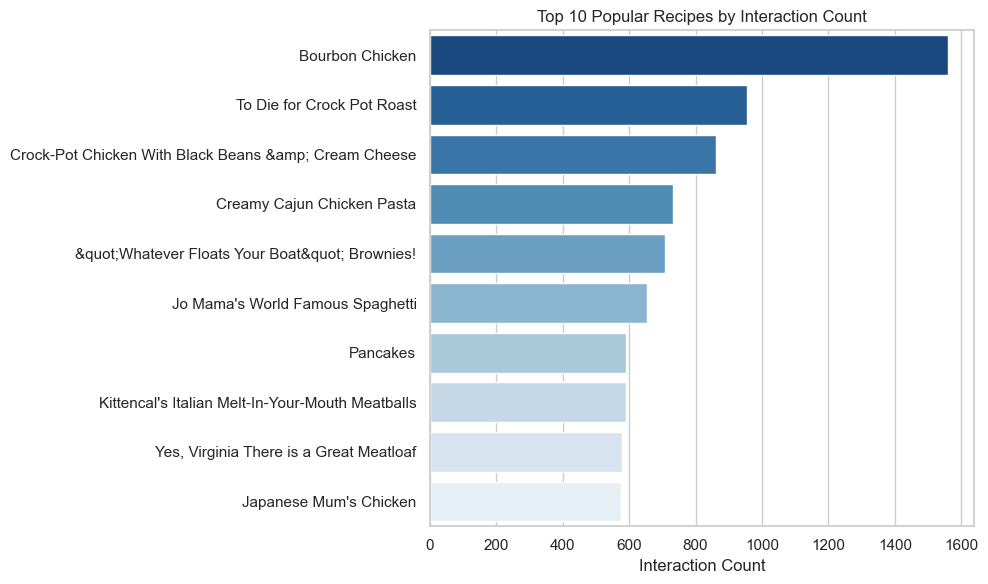

In [4]:
# Plot Top 10 Popular Recipes
plt.figure(figsize=(10, 6))
sns.barplot(data=popularity_df.head(10), x='interaction_count', y='recipe_name', palette='Blues_r')
plt.title('Top 10 Popular Recipes by Interaction Count')
plt.xlabel('Interaction Count')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 3. Rating-Based Recommender

Recommend the highest-rated items that meet a minimum interaction threshold.

In [5]:
min_interactions = 50

# Calculate average rating and interaction count
rating_df = train_df.groupby('recipeid').agg(
    avg_rating=('rating', 'mean'),
    interaction_count=('rating', 'count')
).reset_index()

# Filter by threshold
rating_based_df = rating_df[rating_df['interaction_count'] >= min_interactions]
rating_based_df = rating_based_df.sort_values('avg_rating', ascending=False)

# Merge with recipe names
rating_based_df = rating_based_df.merge(features_df[['item_id', 'recipe_name']], left_on='recipeid', right_on='item_id', how='left')

print(f'Top 10 Highest Rated Recipes (Min {min_interactions} interactions):')
display(rating_based_df.head(10))

Top 10 Highest Rated Recipes (Min 50 interactions):


,recipeid,avg_rating,interaction_count,item_id,recipe_name
0,87689,5.000000,54,87689,Cake Flour Substitute
1,25094,4.966102,59,25094,My Chicken Parmigiana
2,73348,4.962963,54,73348,Turkey Chowder
3,107440,4.961538,52,107440,Oven Cooked Bacon With Black Pepper and Brown ...
4,46365,4.956522,92,46365,Sangria
5,13228,4.955224,67,13228,Honey Mustard
6,4075,4.953125,64,4075,Chocolate Mint Candy (Fudge)
7,42976,4.952381,84,42976,Brown Sugar Bundt Cake
8,10840,4.949153,59,10840,Dry Rub for Barbecued Ribs
9,63621,4.943396,53,63621,Mango Salsa #1


C:\Users\ishan shastri\AppData\Local\Temp\ipykernel_21512\426556737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_based_df.head(10), x='avg_rating', y='recipe_name', palette='Greens_r')


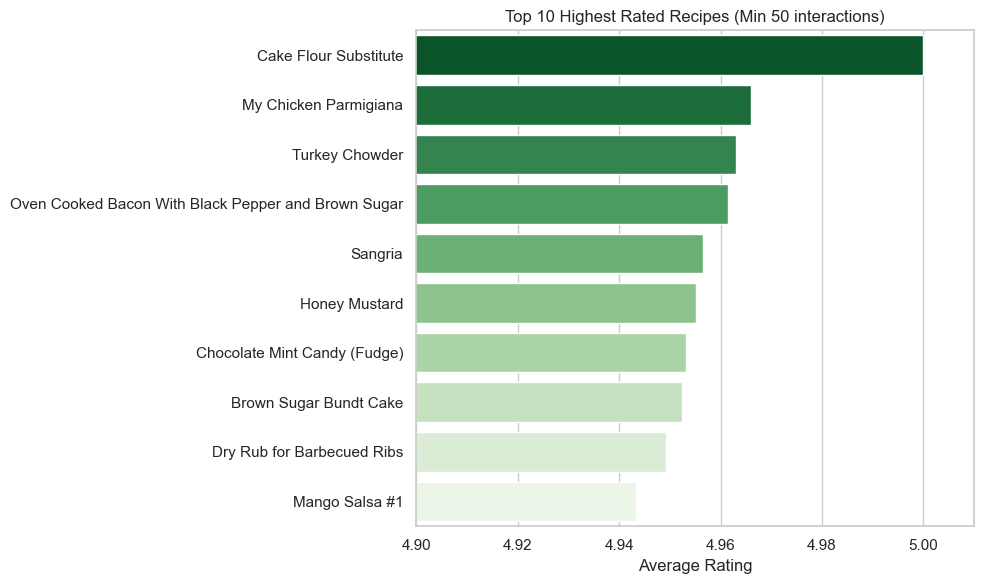

In [6]:
# Plot Top 10 Highest Rated Recipes
plt.figure(figsize=(10, 6))
sns.barplot(data=rating_based_df.head(10), x='avg_rating', y='recipe_name', palette='Greens_r')
plt.xlim(4.9, 5.01) # Zoom in to see differences
plt.title(f'Top 10 Highest Rated Recipes (Min {min_interactions} interactions)')
plt.xlabel('Average Rating')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 4. Save Predictions for Evaluation

For evaluation, we just need the ordered list of items for these baselines.

In [7]:
import pickle

# Top 1000 items should be plenty for evaluation up to K=10
pop_recs = popularity_df['recipeid'].head(1000).tolist()
rating_recs = rating_based_df['recipeid'].head(1000).tolist()

os.makedirs('output', exist_ok=True)
with open('output/pop_recs.pkl', 'wb') as f:
    pickle.dump(pop_recs, f)
    
with open('output/rating_recs.pkl', 'wb') as f:
    pickle.dump(rating_recs, f)
    
print('Saved popularity and rating recommendations to output/')

Saved popularity and rating recommendations to output/
